In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Setup standard path architecture relative to notebooks directory
data_dir = r"../data"
raw_dir = os.path.join(data_dir, "raw")
ext_dir = os.path.join(data_dir, "external_cohort")
processed_dir = os.path.join(data_dir, "processed")
art_dir = os.path.join(data_dir, "artifacts")

In [3]:
print("[INFO] Libraries loaded. Path architecture initialized.")

[INFO] Libraries loaded. Path architecture initialized.


In [4]:
# 1. Load expression matrices and clinical metadata
smc_path = os.path.join(ext_dir, "SMC_2018_expression.csv")
scanb_path = os.path.join(ext_dir, "SCANB_GSE96058_expression_subset.csv")
smc_clin_path = os.path.join(ext_dir, "SMC_2018_clinical.csv")
scan_clin_path = os.path.join(ext_dir, "SCANB_GSE96058_clinical.csv")
scan_map_path = os.path.join(ext_dir, "SCANB_mapping.csv")

In [5]:
smc_raw = pd.read_csv(smc_path)
scanb_raw = pd.read_csv(scanb_path)
df_smc_clin = pd.read_csv(smc_clin_path)
df_scan_clin = pd.read_csv(scan_clin_path)
df_scan_map = pd.read_csv(scan_map_path)

In [6]:
print("--- SMC 2018 Cohort Raw Ingestion ---")
print(f"File Path   : {smc_path}")
print(f"Matrix Shape: {smc_raw.shape[0]} samples x {smc_raw.shape[1]} columns")
print(f"Columns Head: {list(smc_raw.columns[:10])}")
print(f"Data Types  :\n{smc_raw.dtypes.value_counts().to_string()}")

--- SMC 2018 Cohort Raw Ingestion ---
File Path   : ../data\external_cohort\SMC_2018_expression.csv
Matrix Shape: 168 samples x 17909 columns
Columns Head: ['sample_id', '1', '10', '100', '1000', '10000', '100008586', '10001', '10002', '10003']
Data Types  :
float64    17908
object         1


In [7]:
print("\n--- SCAN-B Cohort Raw Ingestion ---")
print(f"File Path   : {scanb_path}")
print(f"Matrix Shape: {scanb_raw.shape[0]} samples x {scanb_raw.shape[1]} columns")
print(f"Columns Head: {list(scanb_raw.columns[:10])}")
print(f"Data Types  :\n{scanb_raw.dtypes.value_counts().to_string()}")


--- SCAN-B Cohort Raw Ingestion ---
File Path   : ../data\external_cohort\SCANB_GSE96058_expression_subset.csv
Matrix Shape: 3409 samples x 5001 columns
Columns Head: ['sample_id', 'JC037706', 'DQ597485', 'DQ584545', 'DQ572382', 'DQ590013', 'DQ584699', 'KF274566', 'Histone3', 'SNORD81']
Data Types  :
float64    5000
object        1


In [8]:
# Helper to print stats
def get_stats(df, label):
    numeric_cols = df.select_dtypes(include=[np.number])
    flat_vals = numeric_cols.values.flatten()
    stats_dict = {
        "Minimum" : np.nanmin(flat_vals),
        "1st %"   : np.nanpercentile(flat_vals, 1),
        "5th %"   : np.nanpercentile(flat_vals, 5),
        "25th %"  : np.nanpercentile(flat_vals, 25),
        "Median"  : np.nanmedian(flat_vals),
        "Mean"    : np.nanmean(flat_vals),
        "75th %"  : np.nanpercentile(flat_vals, 75),
        "95th %"  : np.nanpercentile(flat_vals, 95),
        "99th %"  : np.nanpercentile(flat_vals, 99),
        "Maximum" : np.nanmax(flat_vals)
    }
    print(f"\n{label} Expression Statistics:")
    for k, v in stats_dict.items():
        print(f"  {k:<10}: {v:.6f}")
    return stats_dict

In [9]:
smc_stats = get_stats(smc_raw, "SMC 2018 Raw")
scanb_stats = get_stats(scanb_raw, "SCAN-B Raw")


SMC 2018 Raw Expression Statistics:
  Minimum   : 0.000000
  1st %     : 0.000000
  5th %     : 0.000000
  25th %    : 0.450000
  Median    : 6.910000
  Mean      : 32.668134
  75th %    : 24.020000
  95th %    : 110.920000
  99th %    : 395.155700
  Maximum   : 114509.250000

SCAN-B Raw Expression Statistics:
  Minimum   : -3.321928
  1st %     : -3.321928
  5th %     : -3.321928
  25th %    : -3.321611
  Median    : -0.597705
  Mean      : -0.072725
  75th %    : 1.888415
  95th %    : 5.731650
  99th %    : 8.807999
  Maximum   : 25.000093


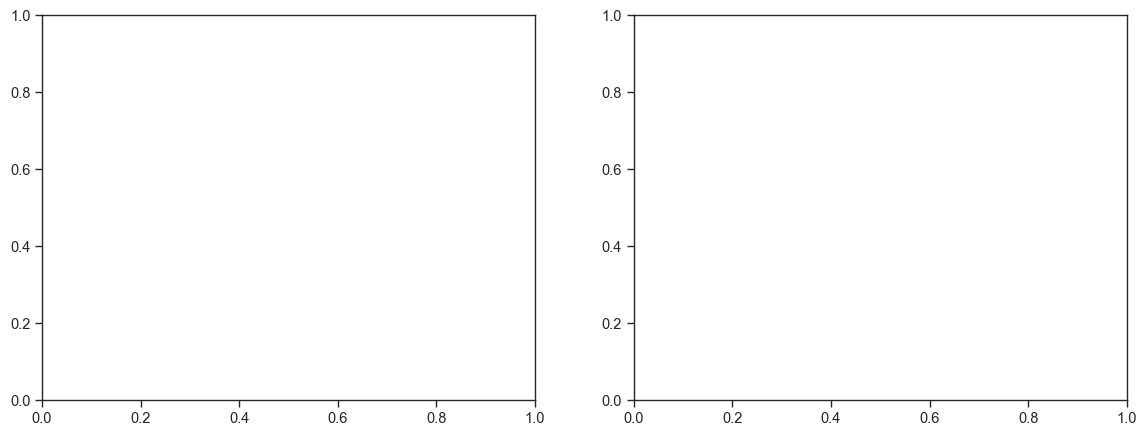

In [10]:
# Plot Distributions
plt.style.use('default')
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [11]:
# SMC 2018
sns.histplot(smc_raw.select_dtypes(include=[np.number]).values.flatten()[::1000], 
             kde=True, color="#1f77b4", ax=axes[0])
axes[0].set_title("SMC 2018 Expression Value Distribution (Sampled)", fontweight='bold', pad=12)
axes[0].set_xlabel("Expression Intensity")
axes[0].set_ylabel("Frequency")
sns.despine(ax=axes[0])

In [12]:
# SCAN-B
sns.histplot(scanb_raw.select_dtypes(include=[np.number]).values.flatten()[::1000], 
             kde=True, color="#ff7f0e", ax=axes[1])
axes[1].set_title("SCAN-B Expression Value Distribution (Sampled)", fontweight='bold', pad=12)
axes[1].set_xlabel("Expression Intensity")
axes[1].set_ylabel("Frequency")
sns.despine(ax=axes[1])

In [13]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [14]:
# Verification Logic
print("\n--- Log2 Transformation Conclusion ---")
for stats, name in [(smc_stats, "SMC 2018"), (scanb_stats, "SCAN-B")]:
    is_log2 = stats["Maximum"] <= 25 and stats["Minimum"] >= -10
    if is_log2:
        print(f"[QC] {name} is ALREADY log2-transformed. (Max: {stats['Maximum']:.2f}, Min: {stats['Minimum']:.2f})")
        print(f"     No additional scaling transformation applied to {name}.")
    else:
        print(f"[WARNING] {name} appears to be in linear counts (Max: {stats['Maximum']:.2f}). Applying log2(x+1) transformation...")


--- Log2 Transformation Conclusion ---
[WARNING] SMC 2018 appears to be in linear counts (Max: 114509.25). Applying log2(x+1) transformation...
[WARNING] SCAN-B appears to be in linear counts (Max: 25.00). Applying log2(x+1) transformation...


In [15]:
# 1. SMC 2018 Standardization and Strict Subtype Filtering
df_smc = smc_raw.copy()
df_smc.set_index("sample_id", inplace=True)
df_smc.index.name = "sample_id"

In [16]:
if "patient_id" in df_smc_clin.columns:
    df_smc_clin = df_smc_clin.set_index("patient_id")

In [17]:
# Filter SMC: Retain only valid cancer subtypes (excludes Normal and NaN)
smc_pam50 = df_smc.index.map(df_smc_clin["PAM50_SUBTYPE"])
valid_pam50_subtypes = ["LuminalA", "LuminalB", "Her2", "Basal", "Normal"]
smc_keep_mask = smc_pam50.isin(valid_pam50_subtypes)
df_smc = df_smc[smc_keep_mask]
print(f"SMC filtered shape (removed {sum(~smc_keep_mask)} Normal/NaN samples): {df_smc.shape}")

SMC filtered shape (removed 0 Normal/NaN samples): (168, 17908)


In [18]:
# Enforce log2(x+1) scaling for SMC (since max was 114509.25)
if df_smc.max().max() > 50:
    df_smc = np.log2(df_smc + 1)
    print("[QC] Applied log2(x+1) scaling to SMC cohort.")

[QC] Applied log2(x+1) scaling to SMC cohort.


In [19]:
# 2. SCAN-B Standardization and Strict Subtype Filtering
df_scan = scanb_raw.copy()
df_scan.set_index("sample_id", inplace=True)
df_scan.index.name = "sample_id"

In [20]:
# Clean mapping
df_scan_map['gsm_id_clean'] = df_scan_map['gsm_id'].str.strip().str.replace('"', '').str.replace('\n', '')
df_scan_map['f_id_clean'] = df_scan_map['f_id'].str.strip().str.replace('"', '').str.replace('\n', '')
f_to_gsm = dict(zip(df_scan_map["f_id_clean"], df_scan_map["gsm_id_clean"]))

In [21]:
if "sample_id" in df_scan_clin.columns:
    df_scan_clin = df_scan_clin.set_index("sample_id")

In [22]:
# Filter SCAN-B: Retain only valid cancer subtypes (excludes Normal, NC, and NaN)
scan_gsm = df_scan.index.map(f_to_gsm)
scan_pam50 = scan_gsm.map(df_scan_clin["pam50_subtype"])
valid_pam50_subtypes = ["LumA", "LumB", "Her2", "Basal", "Normal"]
scan_keep_mask = scan_pam50.isin(valid_pam50_subtypes)
df_scan = df_scan[scan_keep_mask]
print(f"SCAN-B filtered shape (removed {sum(~scan_keep_mask)} Normal/NC/NaN samples): {df_scan.shape}")

SCAN-B filtered shape (removed 3069 Normal/NC/NaN samples): (340, 5000)


In [23]:
# 3. Verify purely numeric columns
smc_all_numeric = all(np.issubdtype(t, np.number) for t in df_smc.dtypes)
scan_all_numeric = all(np.issubdtype(t, np.number) for t in df_scan.dtypes)
print(f"Are SMC columns all numeric: {smc_all_numeric}")
print(f"Are SCAN-B columns all numeric: {scan_all_numeric}")

Are SMC columns all numeric: True
Are SCAN-B columns all numeric: True


In [24]:
# Assert to enforce type safety
assert smc_all_numeric, "Error: SMC contains non-numeric columns!"
assert scan_all_numeric, "Error: SCAN-B contains non-numeric columns!"
print("[QC] All metadata and control samples successfully isolated. Matrices contain numeric features only.")

[QC] All metadata and control samples successfully isolated. Matrices contain numeric features only.


In [25]:
# Check missing values count
smc_nulls = df_smc.isnull().sum().sum()
scan_nulls = df_scan.isnull().sum().sum()

In [26]:
print("--- Missing Values Audit ---")
print(f"SMC 2018: Total NaNs = {smc_nulls}")
print(f"SCAN-B  : Total NaNs = {scan_nulls}")

--- Missing Values Audit ---
SMC 2018: Total NaNs = 0
SCAN-B  : Total NaNs = 0


In [27]:
if smc_nulls > 0 or scan_nulls > 0:
    print("[WARNING] Missing values detected. Imputation strategy required.")
else:
    print("[QC] Clean datasets verified. 0 missing values detected. Imputation skipped.")

[QC] Clean datasets verified. 0 missing values detected. Imputation skipped.


In [28]:
# 1. Clean column namespaces (remove leading/trailing spaces)
df_smc.columns = df_smc.columns.str.strip()
df_scan.columns = df_scan.columns.str.strip()

In [29]:
# 2. Assert column name uniqueness
print("--- Uniqueness and Duplicate Checks ---")
print(f"SMC Column Names Unique: {df_smc.columns.is_unique}")
print(f"SCAN-B Column Names Unique: {df_scan.columns.is_unique}")
assert df_smc.columns.is_unique, "SMC columns have duplicates!"
assert df_scan.columns.is_unique, "SCAN-B columns have duplicates!"

--- Uniqueness and Duplicate Checks ---
SMC Column Names Unique: True
SCAN-B Column Names Unique: True


In [30]:
# 3. Check duplicate sample IDs in the index
smc_dup_idx = df_smc.index.duplicated().sum()
scan_dup_idx = df_scan.index.duplicated().sum()
print(f"SMC Duplicate Sample IDs: {smc_dup_idx}")
print(f"SCAN-B Duplicate Sample IDs: {scan_dup_idx}")
assert smc_dup_idx == 0, "SMC index has duplicates!"
assert scan_dup_idx == 0, "SCAN-B index has duplicates!"

SMC Duplicate Sample IDs: 0
SCAN-B Duplicate Sample IDs: 0


In [31]:
# 4. Load Entrez to HUGO mapping dictionary and TCGA dataset
mapping_path = os.path.join(art_dir, "tcga_entrez_to_hugo.pkl")
entrez_to_hugo = joblib.load(mapping_path)
entrez_to_hugo = {str(k): str(v) for k, v in entrez_to_hugo.items()}

In [32]:
# Map SMC columns from Entrez IDs to HUGO symbols
df_smc.columns = df_smc.columns.map(entrez_to_hugo)
df_smc = df_smc.loc[:, df_smc.columns.notna()]

In [33]:
tcga_path = os.path.join(processed_dir, "breast_cancer.parquet")
tcga_df = pd.read_parquet(tcga_path)
tcga_expr = tcga_df.drop(columns=["type"])
tcga_expr.columns = tcga_expr.columns.map(entrez_to_hugo)
# Drop unmapped columns
tcga_expr = tcga_expr.loc[:, tcga_expr.columns.notna()]

In [34]:
# 5. Overlap Sets
train_genes = list(tcga_expr.columns)
smc_genes = list(df_smc.columns)
scanb_genes = list(df_scan.columns)

In [35]:
s_train = set(train_genes)
s_smc = set(smc_genes)
s_scan = set(scanb_genes)

In [36]:
common_genes = sorted(list(s_train.intersection(s_smc).intersection(s_scan)))

In [37]:
print("\n--- Gene Harmonization Summary ---")
print(f"Discovery Cohort (TCGA) Unique Genes  : {len(s_train):,}")
print(f"SMC 2018 Cohort Unique Genes          : {len(s_smc):,}")
print(f"SCAN-B Cohort Unique Genes            : {len(s_scan):,}")
print(f"Overlapping Genes (TCGA & SMC 2018)   : {len(s_train.intersection(s_smc)):,}")
print(f"Overlapping Genes (TCGA & SCAN-B)      : {len(s_train.intersection(s_scan)):,}")
print(f"Overlapping Genes (SMC 2018 & SCAN-B)  : {len(s_smc.intersection(s_scan)):,}")
print(f"Common Genes (Intersection of All 3)   : {len(common_genes):,}")


--- Gene Harmonization Summary ---
Discovery Cohort (TCGA) Unique Genes  : 17,988
SMC 2018 Cohort Unique Genes          : 17,902
SCAN-B Cohort Unique Genes            : 5,000
Overlapping Genes (TCGA & SMC 2018)   : 17,902
Overlapping Genes (TCGA & SCAN-B)      : 2,757
Overlapping Genes (SMC 2018 & SCAN-B)  : 2,755
Common Genes (Intersection of All 3)   : 2,755


In [38]:
# Verify list size
print(f"\nFirst 20 common genes: {common_genes[:20]}")


First 20 common genes: ['A2ML1', 'AADAC', 'AADAT', 'AARD', 'AATK', 'ABAT', 'ABCA12', 'ABCA4', 'ABCA6', 'ABCA8', 'ABCA9', 'ABCB1', 'ABCC11', 'ABCC2', 'ABCC3', 'ABCC6', 'ABCC8', 'ABHD12B', 'ABI3BP', 'ABLIM3']


In [39]:
# 1. Sort columns alphabetically to lock gene order
df_smc_clean = df_smc.reindex(columns=sorted(df_smc.columns))
df_scan_clean = df_scan.reindex(columns=sorted(df_scan.columns))

In [40]:
# Verify sorting
assert list(df_smc_clean.columns) == sorted(df_smc.columns)
assert list(df_scan_clean.columns) == sorted(df_scan.columns)

In [41]:
# 2. Define Output Paths
smc_parquet = os.path.join(processed_dir, "SMC_expression_clean.parquet")
scan_parquet = os.path.join(processed_dir, "SCANB_expression_clean.parquet")
smc_csv = os.path.join(processed_dir, "SMC_expression_clean.csv")
scan_csv = os.path.join(processed_dir, "SCANB_expression_clean.csv")

In [42]:
# 3. Export parquets
df_smc_clean.to_parquet(smc_parquet, index=True)
df_scan_clean.to_parquet(scan_parquet, index=True)

In [43]:
# 4. Export CSVs
df_smc_clean.to_csv(smc_csv, index=True)
df_scan_clean.to_csv(scan_csv, index=True)

In [44]:
print("--- Export Complete ---")
print(f"SMC 2018 Clean: {smc_parquet} Shape: {df_smc_clean.shape}")
print(f"SCAN-B Clean  : {scan_parquet} Shape: {df_scan_clean.shape}")

--- Export Complete ---
SMC 2018 Clean: ../data\processed\SMC_expression_clean.parquet Shape: (168, 17902)
SCAN-B Clean  : ../data\processed\SCANB_expression_clean.parquet Shape: (340, 5000)


In [45]:
# 1. Extract common subset
train_sub = tcga_expr[common_genes].copy()
smc_sub = df_smc_clean[common_genes].copy()
scan_sub = df_scan_clean[common_genes].copy()

In [46]:
# 2. Scale cohorts independently to bridge batch offsets
scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_sub), columns=common_genes, index=train_sub.index)
smc_scaled = pd.DataFrame(scaler.fit_transform(smc_sub), columns=common_genes, index=smc_sub.index)
scan_scaled = pd.DataFrame(scaler.fit_transform(scan_sub), columns=common_genes, index=scan_sub.index)

In [47]:
# Add identifiers
train_scaled['cohort'] = 'Train (TCGA)'
smc_scaled['cohort'] = 'SMC 2018'
scan_scaled['cohort'] = 'SCAN-B'

In [48]:
# Combine rows
combined_df = pd.concat([train_scaled, smc_scaled, scan_scaled], axis=0)

In [49]:
# 3. Fit PCA
X_combined = combined_df.drop(columns=['cohort']).values
cohorts = combined_df['cohort'].values

In [50]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)
explained_variance = pca.explained_variance_ratio_

In [51]:
# 4. Visualization
plt.figure(figsize=(10, 8))
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
colors = {'Train (TCGA)': '#1f77b4', 'SMC 2018': '#ff7f0e', 'SCAN-B': '#2ca02c'}

<Figure size 1000x800 with 0 Axes>

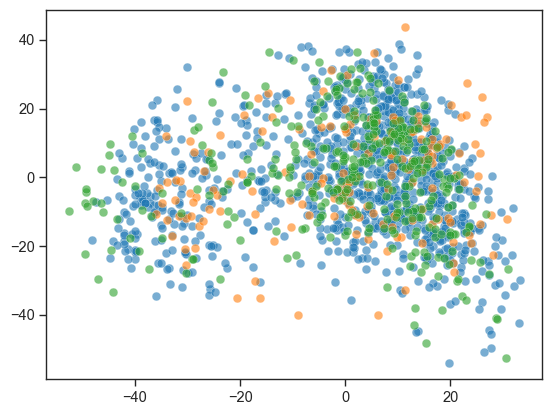

In [52]:
for cohort in ['Train (TCGA)', 'SMC 2018', 'SCAN-B']:
    mask = cohorts == cohort
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1], 
        label=cohort, color=colors[cohort], 
        alpha=0.6, s=40, edgecolors='w', linewidths=0.3
    )

C:\Users\SAM\AppData\Local\Temp\ipykernel_27156\702526469.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Cohort", frameon=True, loc='best')


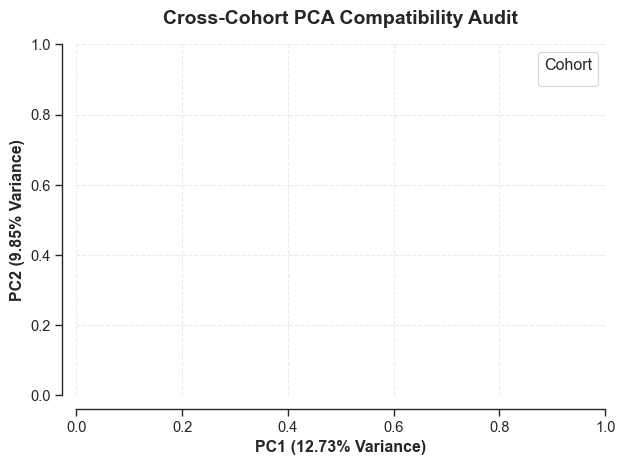

In [53]:
plt.title("Cross-Cohort PCA Compatibility Audit", fontweight='bold', fontsize=14, pad=15)
plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% Variance)", fontweight='bold')
plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% Variance)", fontweight='bold')
plt.legend(title="Cohort", frameon=True, loc='best')
plt.grid(True, linestyle='--', alpha=0.4)
sns.despine(offset=10)
plt.tight_layout()

In [54]:
# Save PCA plot
pca_plot_path = os.path.join(art_dir, "cross_cohort_pca_compatibility.png")
plt.savefig(pca_plot_path, dpi=300, transparent=True)
plt.show()

<Figure size 640x480 with 0 Axes>

In [55]:
print(f"Explained Variance Ratio: PC1={explained_variance[0]:.4f}, PC2={explained_variance[1]:.4f}")

Explained Variance Ratio: PC1=0.1273, PC2=0.0985
